<a href="https://colab.research.google.com/github/xidoudou/ai-agents/blob/main/agent06_language_practicing_multi_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install & Import**

In [34]:
!pip install -q langgraph langchain langchain-anthropic
import os
from google.colab import userdata

os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")


from typing import Literal
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Markdown, Image, display

llm = init_chat_model("anthropic:claude-sonnet-5-5")

**Settings**

Pick from the dropdowns on the right, then re-run this cell. The agents read these settings on every call, so no other cell needs to change.

Tip: when you switch language, also change `thread_id` in section 4 so the old conversation doesn't mix in.

In [35]:
target_language = "German" # @param ["German", "French", "Spanish", "Italian", "Japanese", "Korean", "English"] {allow-input: true}
explain_in = "English" # @param ["Chinese", "English", "German"] {allow-input: true}
level = "intermediate" # @param ["beginner", "intermediate", "advanced"] {allow-input: true}

settings = {"target": target_language, "explain_in": explain_in, "level": level}
print(settings)

{'target': 'German', 'explain_in': 'English', 'level': 'intermediate'}


**State & Supervisor Agent**

The supervisor does one thing: pick one of four agent names. Structured output keeps it from improvising.



In [36]:
class State(MessagesState):
  route: str                    # the supervisors's decision


class Route(BaseModel):
  next: Literal["writing_corrector", "vocab", "grammar_teacher", "quiz"]

SUPERVISOR_PROMPT ="""
You are the router of a {target} learning assistant.
Pick the specialist for the user's latest message. Do not answer it yourself.
- writing_corrector: the user submits their own {target} text (e.g. a diary entry) for correction
- vocab: the user asks what a {target} word mean, or how to say something in {target}
- grammar_teacher: the user wants a {target} grammar topic explained
- quiz: the user asks for practice exerices, or is answering a quiz
"""

def supervisor(state: State):
  decision = llm.with_structured_output(Route,  method="json_schema").invoke([SUPERVISOR_PROMPT.format(**settings), *state["messages"][-4:]])
  print(f"  [->{decision.next}]")
  return {"route": decision.next}

**Four sub-agents**

Same structure for all: system prompt + recent messages -> LLM.

Only the prompt differs.

The prompts are **templates**: `{target}`, `{explain_in}` and `{level}` are filled in from `settings` at call time.

In [46]:
PROMPTS= {
    "writing_corrector":
    """
    You are a {target} writing tutor for a {level} learner. Correct the learner's text:
    1. Give the fullyy corrected text.
    2. List each error, what was wrong, and the rule behind it.
    3. End with one or two things to focus on next time.
    Explain in {explain_in}.
    """,

    "vocab": """You are a {target} vocabulary coach for a {level} learner. For the word or phrase asked about, give:
    1. meaning(s)
    2. the grammatical details that matter in {target} (e.g. gender, plural, irregular forms, reading/pronunciation)
    3. 2-3 natural example sentences with translations
    4. a few related words (synonyms, word family, common collocations)
     Explain in {explain_in}. Keep it short.
     """,

    "grammar_teacher": """You are a {target} grammar teacher for a {level} learner.
     Explain the requested topic systematically: when it is used, how it is formed,
     examples, common mistakes, and 2-3 short exercises with answers at the end. Explain in {explain_in}.""",


    "quiz": """You are a {target} quiz master for a {level} learner.
      If the user asks for a quiz: write 10 numbered questions (mixed: fill-in-the-blank, error correction,
      translation) and do NOT show the answers.
      If the user is answering: grade each answer, give the correct answer and a short explanation,
      then the total score. Instructions and feedback in {explain_in}.""",

}


def get_text(msg) -> str:
    """Return only the answer text, skipping any thinking blocks."""
    if isinstance(msg.content, str):
        return msg.content
    return "".join(block.get("text", "") for block in msg.content if block.get("type") == "text")

def make_agent(name: str):
  """Build a graph node for the agent 'name' from its prompt template"""
  def agent(state: State):
    prompt = PROMPTS[name].format(**settings)
    reply = llm.invoke([SystemMessage(prompt), *state['messages'][-6:]])
    return {"messages": [AIMessage(get_text(reply), name=name)]}
  return agent



**Build the Graph**

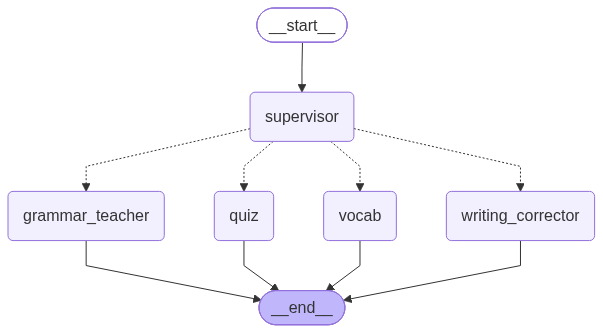

In [47]:
builder = StateGraph(State)
builder.add_node("supervisor", supervisor)
for name in PROMPTS:
  builder.add_node(name, make_agent(name))
  builder.add_edge(name, END)
builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", lambda s: s['route'], list(PROMPTS))
graph = builder.compile(checkpointer = InMemorySaver())

display(Image(graph.get_graph().draw_mermaid_png()))

**CHAT**

In [50]:
config = {"configurable": {"thread_id": "german-5"}}

def chat(text:str):
  result = graph.invoke({"messages": [HumanMessage(text)]}, config)
  display(Markdown(result["messages"][-1].content))

In [49]:
chat("How do you say blue in German?")

  [->vocab]


**Blau** (pronounced *blow*, rhymes with "cow")

**1. Meaning**
- blue (the color)
- colloquially: *drunk* ("blau sein")

**2. Grammar**
- Adjective: *blau*, with normal endings: *ein blaues Auto, der blaue Himmel, eine blaue Jacke*
- Comparative/superlative: *blauer, am blausten*
- As a noun: **das Blau** (the color blue), plural *die Blau* or *die Blautöne* (shades of blue). Usually the noun is uncapitalized only when it's an adjective: *Ich mag Blau.* (noun) vs. *Ich mag blau.* (rare)

**3. Examples**
- *Der Himmel ist heute strahlend blau.* – The sky is brilliantly blue today.
- *Sie trägt ein blaues Kleid.* – She's wearing a blue dress.
- *Nach der Party war er total blau.* – After the party he was totally wasted.

**4. Related words**
- Shades: *hellblau* (light blue), *dunkelblau* (dark blue), *himmelblau* (sky blue), *türkis* (turquoise), *marineblau* (navy)
- Word family: *die Bläue* (blueness), *bläulich* (bluish), *das Blaubeere* → *die Blaubeere* (blueberry)
- Idioms: *blaues Auge* (black eye), *blauer Fleck* (bruise), *mit einem blauen Auge davonkommen* (to get off lightly), *Fahrt ins Blaue* (mystery trip), *blau machen* (to skip work/play hooky)

In [51]:
chat("give me a quiz to learn 10 german words")

  [->quiz]


# German Vocabulary Quiz: 10 Words

**Target words:** die Erfahrung · wahrscheinlich · der Vorschlag · verschieben · die Umgebung · zuverlässig · vermissen · die Besprechung · anstrengend · sich entscheiden

**Instructions:** Answer all 10 questions, then send me your answers for grading.

---

**1. Fill in the blank:**
Ich habe viel ______ als Kellner.

**2. Translate into German:**
"I probably won't come tomorrow."

**3. Error correction** (one mistake):
Sie hat eine gute Vorschlag gemacht.

**4. Fill in the blank:**
Können wir das Meeting auf Montag ______?

**5. Translate into English:**
Die Umgebung hier ist sehr ruhig.

**6. Fill in the blank:**
Mein Bruder ist sehr ______. Er kommt immer pünktlich.

**7. Error correction** (one mistake):
Ich vermisse zu meiner Familie sehr.

**8. Translate into German:**
"The meeting starts at ten o'clock."

**9. Fill in the blank:**
Der Tag war so ______, dass ich sofort eingeschlafen bin.

**10. Error correction** (one mistake):
Ich habe entschieden mich für das blaue Auto.

---

Good luck! Send me your answers (e.g., *1. …, 2. …*) and I'll grade them.

In [52]:
chat("""
1. Erfahrung
2. Ich komme morgen wahrscheinlich nicht.
3. Sie hat einen guten Vorschlag gemacht.
4. verschieben
5. The surroundings here are very quiet.
6. zuverlässig
7. Ich vermisse meine Familie sehr.
8. Die Besprechung beginnt um zehn Uhr.
9. anstrengend
10. Ich habe mich für das blaue Auto entschieden.
""")

  [->quiz]


# Grading

**1. ✅ Correct**: *Erfahrung*
Ich habe viel **Erfahrung** als Kellner. *(I have a lot of experience as a waiter.)* Note that *Erfahrung* is used without an article after *viel*.

**2. ✅ Correct**: *Ich komme morgen wahrscheinlich nicht.*
Good word order. *Wahrscheinlich* comes after the verb and before *nicht*. Alternative: *Morgen komme ich wahrscheinlich nicht.*

**3. ✅ Correct**: *Sie hat einen guten Vorschlag gemacht.*
*Der Vorschlag* is masculine, and as the accusative object it takes *einen guten*.

**4. ✅ Correct**: *verschieben*
Können wir das Meeting auf Montag **verschieben**? *(Can we postpone the meeting to Monday?)*

**5. ✅ Correct**: "The surroundings here are very quiet."
*Die Umgebung* can also mean "the area" or "the neighborhood".

**6. ✅ Correct**: *zuverlässig*
Mein Bruder ist sehr **zuverlässig**. *(My brother is very reliable.)*

**7. ✅ Correct**: *Ich vermisse meine Familie sehr.*
*Vermissen* takes a direct object in the accusative, with no *zu*.

**8. ✅ Correct**: *Die Besprechung beginnt um zehn Uhr.*
You could also say *Die Besprechung fängt um zehn Uhr an.*

**9. ✅ Correct**: *anstrengend*
Der Tag war so **anstrengend**, dass ich sofort eingeschlafen bin. *(The day was so exhausting that I fell asleep right away.)*

**10. ✅ Correct**: *Ich habe mich für das blaue Auto entschieden.*
*Sich entscheiden* is reflexive, and the past participle *entschieden* goes at the end of the clause.

---

## Total score: **10 / 10** 🎉

Excellent work! Would you like another quiz with 10 new words, or a harder one with more complex sentences?